# 5. Why proxies cannot be removed linearly

Notebook 1 showed that dropping columns fails. Notebook 4 showed that projecting
out a direction fails. This one shows **why**, and what the current methods
actually achieve.

The short version: linear methods remove the protected attribute from the space
of *linear* predictors. If the attribute is encoded non-linearly, for example in
the variance or in an interaction rather than in a mean shift, the linear probe
reads chance while the information is untouched.

- Ravfogel et al., *Null It Out: Guarding Protected Attributes by Iterative
  Nullspace Projection* (INLP, ACL 2020)
- Elazar & Goldberg, *Adversarial Removal of Demographic Attributes*
  (`papers/elazar-2018-adversarial-removal.pdf`) - adversarial training removes
  the attribute from the adversary that was trained against, and a freshly
  trained probe gets it back

In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score

RNG = np.random.default_rng(5)
N = 12000
z = RNG.integers(0, 2, N).astype(bool)        # the protected attribute

## A feature set that encodes the attribute two different ways

`a` carries it as a **mean shift**, which is linear and removable.

`b1, b2` carry it as a **difference in spread**. The means are identical; only
the variance differs. No direction in that plane separates the groups, so no
projection can remove it, and a tree finds it immediately.

Real data looks like this. Career gap length, transaction dispersion, and income
volatility all encode group membership in shape rather than in location.

In [2]:
a = RNG.normal(np.where(z, 0.8, -0.8), 1.0, N)             # linear channel

# Four independent variance channels. Each pair has identical group means and
# different spread, so no direction separates the groups. Width matters: with
# only a couple of columns, INLP removes one rank per step and simply deletes
# the feature space, which is a property of the toy and not of the method.
chans = []
for k in range(4):
    radius, angle = RNG.normal(0, 1, N), RNG.normal(0, 1, N)
    scale = np.where(z, 2.2, 0.6)
    chans += [radius * np.cos(angle) * scale, radius * np.sin(angle) * scale]
noise = RNG.normal(0, 1, (N, 3))

X = np.c_[a, np.array(chans).T, noise]
b1, b2 = chans[0], chans[1]
print(f'X has {X.shape[1]} columns')
print(f'group means of b1: {b1[z].mean():+.3f} vs {b1[~z].mean():+.3f}   (identical)')
print(f'group std   of b1: {b1[z].std():.3f} vs {b1[~z].std():.3f}   (not identical)')


X has 12 columns
group means of b1: +0.024 vs -0.005   (identical)
group std   of b1: 1.679 vs 0.441   (not identical)


## Two probes

A **linear probe** is logistic regression. A **non-linear probe** is a
gradient-boosted tree. Both try to recover the protected attribute. AUC 0.5 is
chance. The gap between them is the whole story.

In [3]:
def probe(M, kind, y=None):
    y = z if y is None else y
    model = (LogisticRegression(max_iter=2000) if kind == 'linear'
             else HistGradientBoostingClassifier(random_state=0))
    return cross_val_score(model, M, y, cv=5, scoring='roc_auc').mean()


def report(M, name):
    print(f'{name:<40} linear {probe(M, "linear"):.3f}    non-linear {probe(M, "tree"):.3f}')


print(f'{"":<40} {"linear":>6}    {"non-linear":>10}')
report(X, 'original')
report(X[:, 1:], "drop 'a', the visible proxy")

w = LogisticRegression(max_iter=2000).fit(X, z).coef_[0]
w /= np.linalg.norm(w)
report(X - np.outer(X @ w, w), 'one linear projection')

                                         linear    non-linear


original                                 linear 0.866    non-linear 0.992


drop 'a', the visible proxy              linear 0.499    non-linear 0.983


one linear projection                    linear 0.491    non-linear 0.984


## INLP: iterate the projection until nothing linear survives

Iterative Nullspace Projection is the strongest of the linear family. Fit a
linear classifier, project out its direction, repeat until the classifier can no
longer do better than chance.

In [4]:
def inlp(M, y, max_steps=12, tol=0.01):
    """Ravfogel et al. stop when the probe reaches chance, not when the
    coefficient vector reaches zero. An earlier version of this notebook used
    the norm rule and kept projecting long after the probe was at chance; on
    some seeds it removed all 12 directions and the tree then read
    floating-point residue."""
    P, applied = M.copy(), 0
    for _ in range(max_steps):
        if probe(P, 'linear', y) - 0.5 < tol:
            break
        w = LogisticRegression(max_iter=2000).fit(P, y).coef_[0]
        norm = np.linalg.norm(w)
        if norm < 1e-8:
            break
        P = P - np.outer(P @ (w / norm), w / norm)
        applied += 1
    return P, applied


P, n_proj = inlp(X, z)
print(f'INLP applied {n_proj} projection(s); {X.shape[1]} columns -> '
      f'numerical rank {np.linalg.matrix_rank(P, tol=1e-8)}')
report(P, f'INLP, {n_proj} projection(s)')

# A linear probe on second-order terms of the same data
sq = np.c_[b1**2, b2**2, b1 * b2]
print(f'\n{"linear probe on [b1^2, b2^2, b1*b2]":<40} '
      f'{probe(sq, "linear"):.3f}')


INLP applied 1 projection(s); 12 columns -> numerical rank 11


INLP, 1 projection(s)                    linear 0.491    non-linear 0.984

linear probe on [b1^2, b2^2, b1*b2]      0.831


## Is that one seed?

The earlier norm-based loop gave a different answer on almost every seed: four
projections on some, all twelve on others, and a tree AUC anywhere from 0.68 to
0.98 depending on which. That instability was the stopping rule, not the method.

In [5]:
def one_world(seed):
    R = np.random.default_rng(seed)
    zs = R.integers(0, 2, N).astype(bool)
    aa = R.normal(np.where(zs, 0.8, -0.8), 1.0, N)
    ch = []
    for _ in range(4):
        radius, angle = R.normal(0, 1, N), R.normal(0, 1, N)
        scale = np.where(zs, 2.2, 0.6)
        ch += [radius * np.cos(angle) * scale, radius * np.sin(angle) * scale]
    return np.c_[aa, np.array(ch).T, R.normal(0, 1, (N, 3))], zs


print(f"{'seed':>5}{'projections':>13}{'rank left':>11}{'linear':>9}{'tree':>8}")
for seed in range(8):
    Xs, zs = one_world(seed)
    Ps, applied = inlp(Xs, zs)
    print(f'{seed:>5}{applied:>13}{np.linalg.matrix_rank(Ps, tol=1e-8):>11}'
          f'{probe(Ps, "linear", zs):>9.3f}{probe(Ps, "tree", zs):>8.3f}')


 seed  projections  rank left   linear    tree


    0            1         11    0.488   0.985


    1            1         11    0.499   0.984


    2            1         11    0.476   0.981


    3            1         11    0.504   0.986


    4            1         11    0.497   0.983


    5            1         11    0.491   0.984


    6            1         11    0.487   0.985


    7            1         11    0.490   0.984


## Read the numbers

Dropping the visible proxy takes the linear probe to chance. So does a single
projection. So does INLP. If the linear probe were your evidence you would report
success three times.

The non-linear probe stays well above chance throughout.

Two honest qualifications, both of which matter.

**The stopping rule decides what INLP does, and it is easy to get wrong.** With
the paper's rule - stop when the probe reaches chance - one projection is enough
on 8 seeds out of 8. It leaves rank 11 of 12 standing, the linear probe reads
0.476 to 0.504, and the tree reads 0.981 to 0.986. Nothing was deleted, and
nothing was removed either.

An earlier version stopped when the fitted coefficient vector's norm reached
zero. That kept projecting long after the probe was at chance: four projections
on two seeds, all twelve on two others, leaving rank 1 and a tree score of 0.68
to 0.78 that was floating-point residue. The method was fine; the loop was
measuring nothing. The rank column is printed so that failure is visible.

**"No direction to remove" is basis-dependent.** The last line fits a *linear*
probe to squared and cross terms of the same two features and recovers the
attribute easily. The information is linear in a different basis. What is true is
narrower than "linear methods cannot touch it": a linear method applied *in the
feature basis you were given* cannot remove structure that is non-linear in that
basis, and nothing tells you which basis you were handed. The INLP authors make
the same point.

## So what does work

Nothing removes it cleanly, and that is the honest state of the field.

**Measure instead of assume.** Report the non-linear adversary AUC on the final
representation from a *freshly trained* probe. Elazar & Goldberg's result is that
adversarial training defeats the adversary it was trained against and a new probe
recovers the attribute, so the probe must be independent of the training.

**Constrain the outcome, not the input.** Post-processing (Hardt et al.) sets
group-specific thresholds to equalise a chosen error rate. Auditable, and it
requires keeping the protected attribute. Notebook 3 shows the cost.

**Model the causal structure.** Decide which paths from group membership to
outcome are legitimate and block the others (Kilbertus, Kusner in `papers/`).
Needs a causal graph you are willing to defend.

**Change the target.** Notebook 2. Usually larger than any of the above.


## The picture


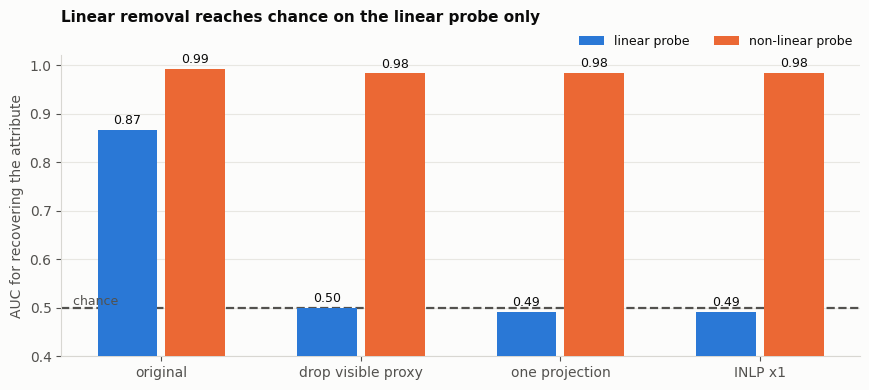

In [6]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

w0 = LogisticRegression(max_iter=2000).fit(X, z).coef_[0]
w0 /= np.linalg.norm(w0)
variants = [('original', X),
            ("drop visible proxy", X[:, 1:]),
            ('one projection', X - np.outer(X @ w0, w0)),
            (f'INLP x{n_proj}', P)]
lin = [probe(M, 'linear') for _, M in variants]
non = [probe(M, 'tree') for _, M in variants]

fig, ax = plt.subplots(figsize=(8.8, 4.0))
x = np.arange(len(variants))
ax.bar(x - 0.17, lin, 0.30, label='linear probe', color=BLUE, zorder=3)
ax.bar(x + 0.17, non, 0.30, label='non-linear probe', color=ORANGE, zorder=3)
for xi, (lv, nv) in zip(x, zip(lin, non)):
    ax.text(xi - 0.17, lv + 0.012, f'{lv:.2f}', ha='center', fontsize=9, color=INK)
    ax.text(xi + 0.17, nv + 0.012, f'{nv:.2f}', ha='center', fontsize=9, color=INK)
ax.axhline(0.5, color=MUTED, lw=1.6, ls='--')
ax.text(0.01, 0.5, ' chance', color=MUTED, fontsize=9, va='bottom', ha='left',
        transform=ax.get_yaxis_transform())
ax.set_xticks(x, [n for n, _ in variants])
ax.set_ylim(0.4, 1.02)
ax.legend(frameon=False, ncol=2, fontsize=9, loc='lower right', bbox_to_anchor=(1.0, 1.0), borderaxespad=0.2)
tidy(ax, xgrid=False)
ax.set_ylabel('AUC for recovering the attribute')
ax.set_title('Linear removal reaches chance on the linear probe only',
             loc='left', pad=24)
fig.tight_layout()
plt.savefig('../figures/05_linear_vs_nonlinear.png', dpi=150, bbox_inches='tight')
plt.show()